## Instalaciones

In [2]:
!pip install pycryptodomex pillow matplotlib pytest ipykernel

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl (73 kB)
Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----

## Importaciones 

In [3]:
import math
import textwrap
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt

from Cryptodome.Cipher import AES, DES
from Cryptodome.Util.Padding import pad, unpad

from src.utils import (
    generate_des_key,
    generate_3des_key,
    generate_aes_key,
    generate_iv,
    pkcs7_pad,
    pkcs7_unpad,
)
from src.des_cipher import encrypt_des_ecb, decrypt_des_ecb
from src.tripledes_cipher import encrypt_3des_cbc, decrypt_3des_cbc
from src.aes_cipher import encrypt_image_aes_ecb, encrypt_image_aes_cbc

In [4]:
def bytes_to_hex_blocks(data: bytes, block_size: int):
    return [data[i:i+block_size].hex() for i in range(0, len(data), block_size)]


def print_hex_blocks(title: str, data: bytes, block_size: int):
    print(title)
    blocks = bytes_to_hex_blocks(data, block_size)
    for i, block in enumerate(blocks, 1):
        print(f"Bloque {i:02d}: {block}")
    print()


def show_image(path: str, title: str):
    img = Image.open(path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_three_images(original_path: str, ecb_path: str, cbc_path: str):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    original = Image.open(original_path)
    ecb = Image.open(ecb_path)
    cbc = Image.open(cbc_path)

    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(ecb)
    axes[1].set_title("AES-ECB")
    axes[1].axis("off")

    axes[2].imshow(cbc)
    axes[2].set_title("AES-CBC")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## 2.1 Análisis de Tamaños de Clave (4 puntos)
Pregunta: ¿Qué tamaño de clave está usando para DES, 3DES y AES? Para cada uno:
- Indique el tamaño en bits y bytes
- Explique por qué DES se considera inseguro hoy en día
- Calcule cuánto tiempo tomaría un ataque de fuerza bruta con hardware moderno

Requisito:
- Incluya un snippet de código que muestre cómo genera cada clave y su longitud.


In [5]:
des_keys = 2 ** 56
tdes_112 = 2 ** 112
tdes_168 = 2 ** 168
aes_128 = 2 ** 128
aes_256 = 2 ** 256

print("Espacio de claves")
print(f"DES (56 bits):     {des_keys:,}")
print(f"3DES 2-key:        {tdes_112:,}")
print(f"3DES 3-key:        {tdes_168:,}")
print(f"AES-128:           {aes_128:,}")
print(f"AES-256:           {aes_256:,}")

Espacio de claves
DES (56 bits):     72,057,594,037,927,936
3DES 2-key:        5,192,296,858,534,827,628,530,496,329,220,096
3DES 3-key:        374,144,419,156,711,147,060,143,317,175,368,453,031,918,731,001,856
AES-128:           340,282,366,920,938,463,463,374,607,431,768,211,456
AES-256:           115,792,089,237,316,195,423,570,985,008,687,907,853,269,984,665,640,564,039,457,584,007,913,129,639,936


In [6]:
tests_per_second = 10**12
seconds = des_keys / tests_per_second
hours = seconds / 3600
days = hours / 24

print("Fuerza bruta estimada para DES")
print(f"Claves por segundo: {tests_per_second:e}")
print(f"Segundos: {seconds:,.2f}")
print(f"Horas:    {hours:,.2f}")
print(f"Días:     {days:,.2f}")

Fuerza bruta estimada para DES
Claves por segundo: 1.000000e+12
Segundos: 72,057.59
Horas:    20.02
Días:     0.83


¿Qué tamaño de clave está usando para DES, 3DES y AES? Para cada uno:
o Indique el tamaño en bits y bytes
o Explique por qué DES se considera inseguro hoy en día
o Calcule cuánto tiempo tomaría un ataque de fuerza bruta con hardware moderno

DES es inseguro porque su clave efectiva es de solo 56 bits.
Ese tamaño de clave ya no ofrece protección suficiente contra ataques de fuerza bruta.
AES-128 y AES-256 tienen espacios de claves muchísimo mayores y siguen siendo seguros.
3DES mejora a DES, pero hoy se considera obsoleto por su bajo rendimiento y bloque de 64 bits.

## 2.2 Comparación de Modos de Operación (5 puntos)
Pregunta: Compare ECB vs CBC mostrando:
- ¿Qué modo de operación implementó en cada algoritmo?
- ¿Cuáles son las diferencias fundamentales entre ECB y CBC?
- ¿Se puede notar la diferencia directamente en una imagen?

Requisitos:
- Incluya las tres imágenes lado a lado: original, cifrada con ECB, cifrada con CBC
- Señale específicamente qué patrones son visibles en ECB pero no en CBC
- Proporcione el código exacto que usó para generar estas imágenes

In [7]:
original_path = "images/original.png"
ecb_path = "images/aes_ecb.png"
cbc_path = "images/aes_cbc.png"

key = generate_aes_key(256)

encrypt_image_aes_ecb(original_path, ecb_path, key)
iv_cbc = encrypt_image_aes_cbc(original_path, cbc_path, key)

print("Imagen original:", original_path)
print("Imagen AES-ECB:", ecb_path)
print("Imagen AES-CBC:", cbc_path)
print("IV CBC:", iv_cbc.hex())

Imagen original: images/original.png
Imagen AES-ECB: images/aes_ecb.png
Imagen AES-CBC: images/aes_cbc.png
IV CBC: c3584e0359f6504f6ade59fa889dbf72


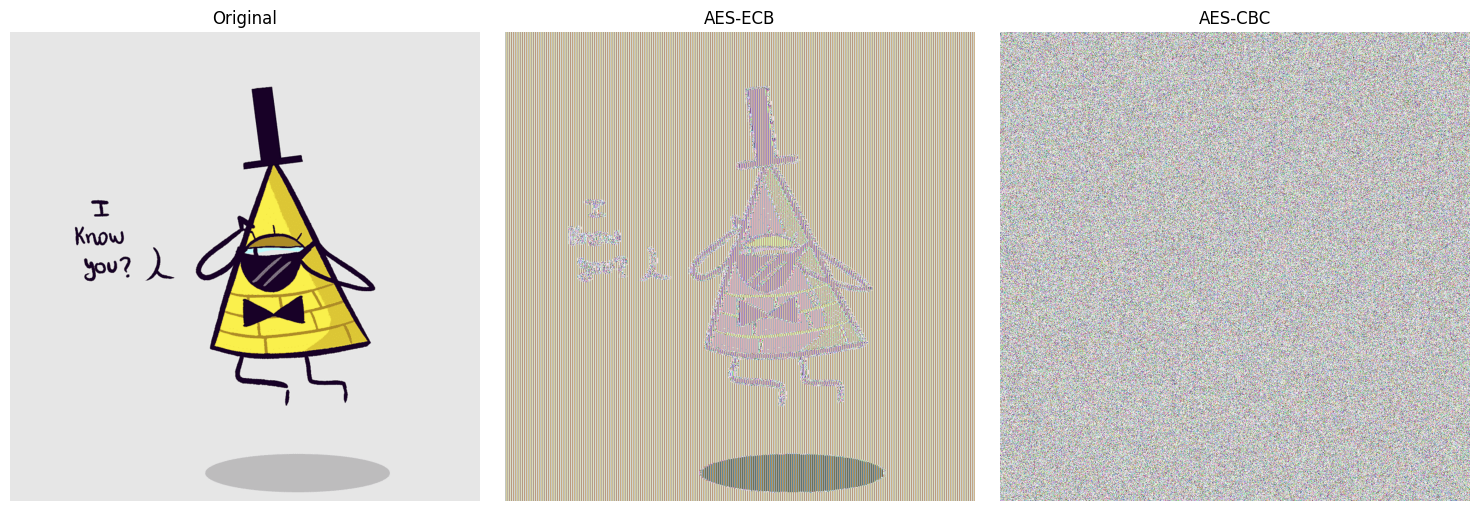

In [8]:
show_three_images(original_path, ecb_path, cbc_path)

En ECB, bloques iguales del plaintext producen bloques iguales del ciphertext.
Por eso se conservan patrones visibles de la imagen original.

En CBC, cada bloque depende del bloque anterior y del IV.
Eso rompe los patrones repetidos y produce una imagen visualmente más aleatoria.

## 2.3 Vulnerabilidad de ECB (6 puntos)
Pregunta: ¿Por qué no debemos usar ECB en datos sensibles?
Requisitos:
- Cree un ejemplo que muestre cómo bloques idénticos producen cifrados idénticos
- Cifre un mensaje que contenga texto repetido (ej: "ATAQUE ATAQUE ATAQUE") con ECB y CBC
- Muestre en hexadecimal cómo los bloques cifrados son iguales en ECB pero diferentes en CBC
- Explique qué información podría filtrar esto en un escenario real

In [9]:
message = b"ATAQUEATAQUEATAQUEATAQUE"
print("Mensaje original:", message)

des_key = generate_des_key()
cbc_key = generate_aes_key(128)
cbc_iv = generate_iv(16)

print("Clave DES:", des_key.hex())
print("Clave AES:", cbc_key.hex())
print("IV CBC:", cbc_iv.hex())

Mensaje original: b'ATAQUEATAQUEATAQUEATAQUE'
Clave DES: 4b644c5ffc462b24
Clave AES: df8ac57572a91be711c6d1b87d4ff2a9
IV CBC: 87cb36847c5343c6f74adc89c4dad75a


In [10]:
cipher_ecb = AES.new(cbc_key, AES.MODE_ECB)
padded_message = pad(message, 16)
ciphertext_ecb = cipher_ecb.encrypt(padded_message)

print_hex_blocks("ECB - Plaintext en bloques:", padded_message, 16)
print_hex_blocks("ECB - Ciphertext en bloques:", ciphertext_ecb, 16)

ECB - Plaintext en bloques:
Bloque 01: 41544151554541544151554541544151
Bloque 02: 55454154415155450808080808080808

ECB - Ciphertext en bloques:
Bloque 01: 86b9bb595333c45a30da9ea213444e46
Bloque 02: 9999b160c1514a84730efba2fe05b837



In [11]:
cipher_cbc = AES.new(cbc_key, AES.MODE_CBC, iv=cbc_iv)
ciphertext_cbc = cipher_cbc.encrypt(padded_message)

print_hex_blocks("CBC - Plaintext en bloques:", padded_message, 16)
print_hex_blocks("CBC - Ciphertext en bloques:", ciphertext_cbc, 16)

CBC - Plaintext en bloques:
Bloque 01: 41544151554541544151554541544151
Bloque 02: 55454154415155450808080808080808

CBC - Ciphertext en bloques:
Bloque 01: 7584a0116079e8d124550fda6ad71427
Bloque 02: 9ba26edc7288176fcdf0a366e24e08ad



En ECB, si dos bloques del mensaje son iguales, sus bloques cifrados también serán iguales.
En CBC, aunque los bloques de entrada sean iguales, el encadenamiento hace que los bloques cifrados cambien.
Por eso ECB filtra patrones y CBC los oculta mejor.

## 2.4 Vector de Inicialización (IV) (4 puntos)
Pregunta: ¿Qué es el IV y por qué es necesario en CBC pero no en ECB?
Requisitos:
- Implemente un experimento: cifre el mismo mensaje dos veces con CBC usando:
- El mismo IV
- IVs diferentes
- Muestre cómo los cifrados resultantes son diferentes en el caso 2
- Explique qué pasaría si un atacante intercepta mensajes cifrados con el mismo IV

In [12]:
plaintext = b"Este es un mensaje de prueba para demostrar el efecto del IV en CBC."
plaintext_padded = pad(plaintext, 16)

key = generate_aes_key(128)
iv1 = generate_iv(16)
iv2 = generate_iv(16)

cipher1 = AES.new(key, AES.MODE_CBC, iv=iv1)
cipher2 = AES.new(key, AES.MODE_CBC, iv=iv1)
cipher3 = AES.new(key, AES.MODE_CBC, iv=iv2)

ct1 = cipher1.encrypt(plaintext_padded)
ct2 = cipher2.encrypt(plaintext_padded)
ct3 = cipher3.encrypt(plaintext_padded)

print("Caso 1 - mismo IV")
print("CT1:", ct1.hex())
print("CT2:", ct2.hex())
print("¿Son iguales?", ct1 == ct2)
print()

print("Caso 2 - IV diferente")
print("CT1:", ct1.hex())
print("CT3:", ct3.hex())
print("¿Son iguales?", ct1 == ct3)

Caso 1 - mismo IV
CT1: a9fd43cdc82a15a33a1c1a8149be9839436d5e0b91eddcb4968502db72e72a16857977e6373a7acc16e3fa3b4d7387ac5ed2e4fb086782c6ac28c7c57d916727b6191948b42b1212a81e373b69a8358e
CT2: a9fd43cdc82a15a33a1c1a8149be9839436d5e0b91eddcb4968502db72e72a16857977e6373a7acc16e3fa3b4d7387ac5ed2e4fb086782c6ac28c7c57d916727b6191948b42b1212a81e373b69a8358e
¿Son iguales? True

Caso 2 - IV diferente
CT1: a9fd43cdc82a15a33a1c1a8149be9839436d5e0b91eddcb4968502db72e72a16857977e6373a7acc16e3fa3b4d7387ac5ed2e4fb086782c6ac28c7c57d916727b6191948b42b1212a81e373b69a8358e
CT3: a622cd5795b980cb9d884b00b089c7564894659923c37ec5f060dd15d547abd347fc9c7790dae8fafa2bf93dad4227090f24fe7762c6252061d500ac984d2bc201fefbec96678a1b06a58380f7daf14e
¿Son iguales? False


Si se usa la misma clave, el mismo mensaje y el mismo IV, el ciphertext resultante será igual.
Si cambia el IV, el ciphertext cambia aunque el mensaje y la clave sean los mismos.
Por eso el IV debe ser único y aleatorio en CBC.

## 2.5 Padding (3 puntos)
Pregunta: ¿Qué es el padding y por qué es necesario?
Requisitos:

- Muestre el resultado de su función pkcs7_pad con diferentes mensajes:

    - Mensaje de 5 bytes
    - Mensaje de 8 bytes (exactamente un bloque de DES)
    - Mensaje de 10 bytes
    - Explique byte por byte qué se agregó en cada caso
    - Demuestre que su función pkcs7_unpad recupera el mensaje original

In [13]:
cases = [
    b"ABCDE",
    b"12345678",
    b"ABCDEFGHIJ",
]

for data in cases:
    padded = pkcs7_pad(data, 8)
    print(f"Mensaje original ({len(data)} bytes): {data}")
    print("Hex original: ", data.hex())
    print("Hex padded:   ", padded.hex())
    print("Bytes padding:", padded[len(data):].hex())
    print("Valor último byte:", padded[-1])
    print("-" * 60)

Mensaje original (5 bytes): b'ABCDE'
Hex original:  4142434445
Hex padded:    4142434445030303
Bytes padding: 030303
Valor último byte: 3
------------------------------------------------------------
Mensaje original (8 bytes): b'12345678'
Hex original:  3132333435363738
Hex padded:    31323334353637380808080808080808
Bytes padding: 0808080808080808
Valor último byte: 8
------------------------------------------------------------
Mensaje original (10 bytes): b'ABCDEFGHIJ'
Hex original:  4142434445464748494a
Hex padded:    4142434445464748494a060606060606
Bytes padding: 060606060606
Valor último byte: 6
------------------------------------------------------------


- Si el mensaje mide 5 bytes y el bloque es de 8, faltan 3 bytes.
  Se agregan 03 03 03.
- Si el mensaje ya mide 8 bytes exactos, se agrega un bloque completo:
  08 08 08 08 08 08 08 08.
- Si el mensaje mide 10 bytes, faltan 6 bytes para llegar a 16 en el segundo bloque.
  Se agregan 06 06 06 06 06 06.

## 2.6 Recomendaciones de Uso (3 puntos)
Pregunta: ¿En qué situaciones se recomienda cada modo de operación? ¿Cómo elegir un modo seguro
en cada lenguaje de programación?
Requisitos:

- Tabla comparativa de modos (ECB, CBC, CTR, GCM)
- Para cada modo: casos de uso recomendados y desventajas
- Código de ejemplo en al menos 2 lenguajes diferentes mostrando cómo usar un modo seguro
- Mención específica a modos AEAD como GCM

In [14]:
comparison = [
    ["ECB", "No", "Baja", "Sí", "No recomendado"],
    ["CBC", "Sí", "Media-Alta", "No en cifrado secuencial", "Archivos y almacenamiento"],
    ["CTR", "Sí/Nonce", "Alta", "Sí", "Streaming y alto rendimiento"],
    ["GCM", "Sí/Nonce", "Muy alta", "Sí", "Cifrado autenticado moderno"],
]

headers = ["Modo", "IV/Nonce", "Seguridad", "Paralelizable", "Uso típico"]

header_line = " | ".join(headers)
separator = " | ".join(["---"] * len(headers))

print(header_line)
print(separator)

for row in comparison:
    print(" | ".join(row))

Modo | IV/Nonce | Seguridad | Paralelizable | Uso típico
--- | --- | --- | --- | ---
ECB | No | Baja | Sí | No recomendado
CBC | Sí | Media-Alta | No en cifrado secuencial | Archivos y almacenamiento
CTR | Sí/Nonce | Alta | Sí | Streaming y alto rendimiento
GCM | Sí/Nonce | Muy alta | Sí | Cifrado autenticado moderno


GCM es un modo AEAD (Authenticated Encryption with Associated Data).
Además de confidencialidad, también ofrece integridad y autenticidad.
Eso significa que no solo cifra los datos, sino que también detecta modificaciones no autorizadas.
Por eso GCM es preferido en protocolos modernos como TLS.

In [15]:
python_example = '''
from Cryptodome.Cipher import AES
from Cryptodome.Random import get_random_bytes
from Cryptodome.Util.Padding import pad, unpad

key = get_random_bytes(32)
iv = get_random_bytes(16)
plaintext = b"Mensaje de ejemplo"

cipher = AES.new(key, AES.MODE_CBC, iv=iv)
ciphertext = cipher.encrypt(pad(plaintext, 16))

decipher = AES.new(key, AES.MODE_CBC, iv=iv)
recovered = unpad(decipher.decrypt(ciphertext), 16)

print(recovered)
'''

print(python_example)


from Cryptodome.Cipher import AES
from Cryptodome.Random import get_random_bytes
from Cryptodome.Util.Padding import pad, unpad

key = get_random_bytes(32)
iv = get_random_bytes(16)
plaintext = b"Mensaje de ejemplo"

cipher = AES.new(key, AES.MODE_CBC, iv=iv)
ciphertext = cipher.encrypt(pad(plaintext, 16))

decipher = AES.new(key, AES.MODE_CBC, iv=iv)
recovered = unpad(decipher.decrypt(ciphertext), 16)

print(recovered)



In [16]:
javascript_example = r'''
const crypto = require("crypto");

const key = crypto.randomBytes(32);
const iv = crypto.randomBytes(16);
const plaintext = "Mensaje de ejemplo";

const cipher = crypto.createCipheriv("aes-256-cbc", key, iv);
let ciphertext = cipher.update(plaintext, "utf8", "hex");
ciphertext += cipher.final("hex");

const decipher = crypto.createDecipheriv("aes-256-cbc", key, iv);
let recovered = decipher.update(ciphertext, "hex", "utf8");
recovered += decipher.final("utf8");

console.log(recovered);
'''

print(javascript_example)


const crypto = require("crypto");

const key = crypto.randomBytes(32);
const iv = crypto.randomBytes(16);
const plaintext = "Mensaje de ejemplo";

const cipher = crypto.createCipheriv("aes-256-cbc", key, iv);
let ciphertext = cipher.update(plaintext, "utf8", "hex");
ciphertext += cipher.final("hex");

const decipher = crypto.createDecipheriv("aes-256-cbc", key, iv);
let recovered = decipher.update(ciphertext, "hex", "utf8");
recovered += decipher.final("utf8");

console.log(recovered);



- DES es inseguro por su clave efectiva de 56 bits.
- 3DES mejora la seguridad, pero hoy se considera obsoleto.
- AES es el estándar moderno.
- ECB no debe usarse para datos estructurados porque revela patrones.
- CBC mejora la confidencialidad gracias al IV y al encadenamiento.
- CTR y GCM son modos modernos más flexibles.
- GCM añade autenticación e integridad, por eso es ampliamente recomendado.